# Data Exploration

### Helper Funcion

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


def load_data(file_path):
    """
    Load data from a CSV file.

    Parameters:
    file_path (str): The path to the CSV file.

    Returns:
    pd.DataFrame: A DataFrame containing the loaded data.
    """
    try:
        data = pd.read_csv(file_path)
        return data
    except Exception as e:
        print(f"An error occurred while loading the data: {e}")
        return None

Matplotlib is building the font cache; this may take a moment.


### Patients

In [2]:
patients = load_data("data/output/csv/patients.csv")
if patients is not None:
    print(patients.columns)

Index(['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX',
       'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE',
       'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE',
       'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES',
       'HEALTHCARE_COVERAGE', 'INCOME'],
      dtype='str')


### Encounters

In [3]:
encounters = load_data("data/output/csv/encounters.csv")
if encounters is not None:
    print(encounters.columns)

Index(['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER', 'PAYER',
       'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST',
       'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE',
       'REASONDESCRIPTION'],
      dtype='str')


### Conditions

In [4]:
conditions = load_data("data/output/csv/conditions.csv")
if conditions is not None:
    print(conditions.columns)

Index(['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'SYSTEM', 'CODE',
       'DESCRIPTION'],
      dtype='str')


## How frequently do patients interact with the healthcare system?
Count encounters per PatientID.

In [5]:
# count encounters per patient
counts = encounters["PATIENT"].value_counts()

print(counts)

PATIENT
dde60d95-00ae-3c50-e778-fcc752a97b58    499
e478a0b9-66f8-1d66-bb6a-4afbd7b52447    252
e34204b8-671b-2931-ee4f-0cbb1fdaf6ec    204
822e45b3-1f42-c20c-3d66-409ec45146fe    203
6f818c2a-fd64-9ca6-ebcd-5f243e1f7f2f    173
                                       ... 
dc584fa0-85ac-f2ac-cbb1-82fde6c4d43b      6
1f8603d4-db6b-7af3-c032-71ab22849aa8      5
50709ffc-55c6-1b0d-5f37-c72fd3fa87fb      5
39a0c8fb-6bfd-0bbc-b346-170d1cfc8143      5
d80f1dd0-367c-509a-c518-1d0a7ce8b046      2
Name: count, Length: 114, dtype: int64


Extract max and min values & average encounters.

In [6]:
print("max:", counts.max(), "min:", counts.min(), "mean:", counts.mean())

max: 499 min: 2 mean: 45.93859649122807


### Histogramm of encounters per patient
Shows that most patients have <75 encounters.

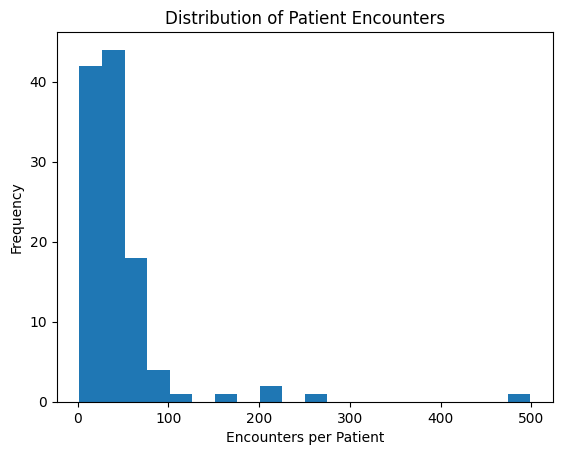

In [8]:
counts.plot(kind="hist", bins=20)

plt.xlabel("Encounters per Patient")
plt.title("Distribution of Patient Encounters")

plt.show()

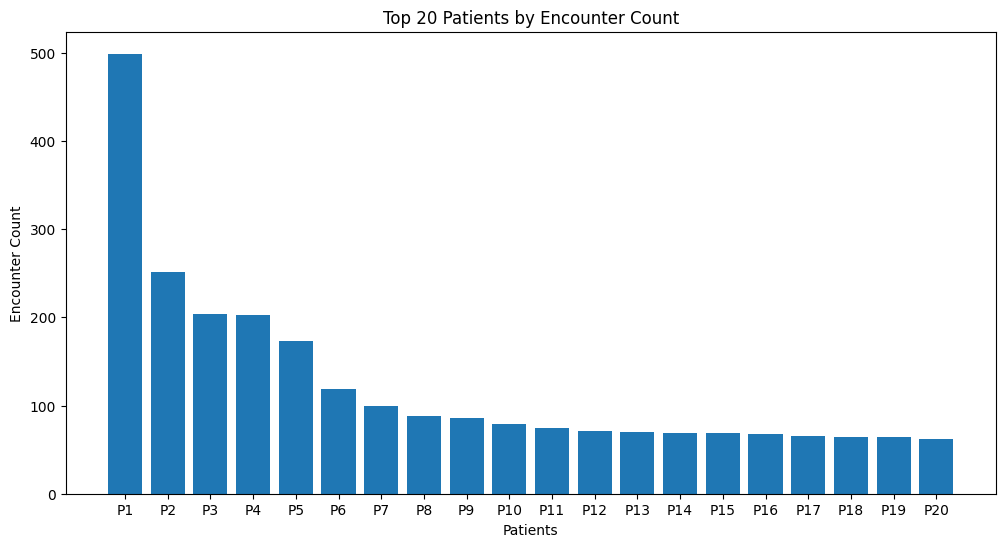

In [ ]:
counts_df = (
    encounters["PATIENT"]
    .value_counts()
    .head(20)
)
# replace labels for better readability
labels = [f"P{i+1}" for i in range(len(counts_df))]

plt.figure(figsize=(12, 6))
plt.bar(labels, counts_df.values)

plt.xlabel("Patients")
plt.ylabel("Encounter Count")
plt.title("Top 20 Patients by Encounter Count")

plt.show()